# Exploratory Data Analysis (EDA)

This notebook performs exploratory data analysis on the Student Dropout dataset. The objective is to understand the dataset structure, identify data quality issues, analyze the target variable, and explore feature distributions before preprocessing and model development.

In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("ggplot")

## 1. Dataset Load in Python

In [107]:
df = pd.read_csv("../dataset/data.csv", sep=";")
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


### Observation

The dataset was successfully loaded using a semicolon (;) as the delimiter. The dataset contains 37 columns, including the Target column, which will be used as the prediction label in this research.

## 2. Basic Dataset Information

In [108]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                          4424

### Observation

The dataset contains 4,424 records and 37 columns. All columns have 4,424 non-null values, indicating that there are no missing values in the dataset. The dataset consists of 29 integer features, 7 floating-point features, and 1 categorical target variable stored as a string. With a memory usage of approximately 1.2 MB, the dataset is compact and suitable for efficient exploratory data analysis and machine learning.

In [109]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Marital status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application mode,4424.0,18.669078,17.484682,1.00,1.00,17.000000,39.000000,57.000000
Application order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,8856.642631,2063.566416,33.00,9085.00,9238.000000,9556.000000,9991.000000
Daytime/evening attendance\t,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous qualification,4424.0,4.577758,10.216592,1.00,1.00,1.000000,1.000000,43.000000
Previous qualification (grade),4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000
Nacionality,4424.0,1.873192,6.914514,1.00,1.00,1.000000,1.000000,109.000000
Mother's qualification,4424.0,19.561935,15.603186,1.00,2.00,19.000000,37.000000,44.000000
Father's qualification,4424.0,22.275316,15.343108,1.00,3.00,19.000000,37.000000,44.000000


### Observation

The descriptive statistics provide an overview of the numerical features in the dataset. Most numerical variables contain 4,424 observations, confirming there are no missing values. For example, the average admission grade is approximately 132.61, with values ranging from 95 to 190, indicating a moderate variation among students. These statistics help identify the overall distribution and range of the numerical features before further analysis.

In [110]:
df.describe(include="object")

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11248\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,Target
count,4424
unique,3
top,Graduate
freq,2209


### Observation

The target variable contains three unique classes: Graduate, Dropout, and Enrolled. The most frequent class is Graduate, appearing 2,209 times out of 4,424 records. This suggests that Graduate is the dominant class in the dataset, although the exact class distribution will be examined later using visualization.

In [111]:
df.isnull().sum()

Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance\t                      0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrol

### Observation

No missing values were found in any of the 37 columns. Therefore, no data imputation or removal of records is required before proceeding with exploratory data analysis and machine learning.

In [112]:
df.duplicated().sum()

np.int64(0)

### Observation

No duplicate rows were found in the dataset. Each student record is unique, so no duplicate removal is required before further analysis.

In [113]:
df["Target"].value_counts()

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

### Observation

The target variable consists of three classes: Graduate, Dropout, and Enrolled. Graduate is the largest class with 2,209 students, followed by Dropout with 1,421 students, while Enrolled is the smallest class with 794 students. This indicates a moderate class imbalance that should be considered during model development and evaluation.

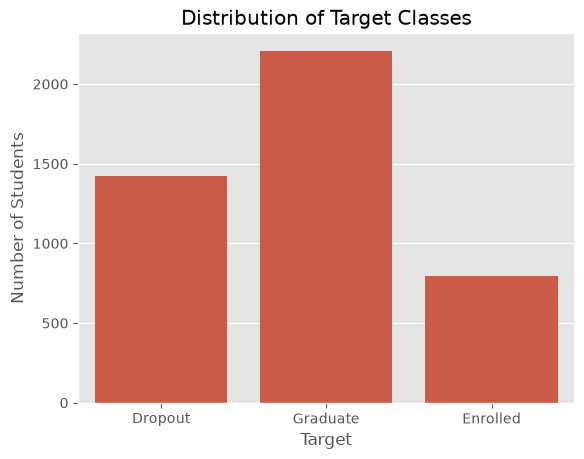

In [114]:
sns.countplot(data=df, x="Target")

plt.title("Distribution of Target Classes")
plt.xlabel("Target")
plt.ylabel("Number of Students")

plt.savefig("../results/eda/class_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

### Observation

The class distribution shows that **Graduate** is the largest class with 2,209 students, followed by **Dropout** with 1,421 students, while **Enrolled** is the smallest class with 794 students. The dataset exhibits a moderate class imbalance, meaning the classes are not equally represented. This should be considered during model training and evaluation to ensure the model performs well across all classes.

In [115]:
numerical = df.select_dtypes(include=np.number).columns
categorical = df.select_dtypes(exclude=np.number).columns

print("Numerical Features:")
print(numerical)

print("\nCategorical Features:")
print(categorical)

Numerical Features:
Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance\t', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       '

### Observation

Based on the data types, the dataset contains 36 numerical features and one categorical feature (Target). However, several integer-valued features such as Gender, Debtor, and Scholarship holder represent categorical variables encoded as numeric values. This distinction will be considered during data interpretation and model development.

C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\utils.py:61: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11248\4109785802.py:10: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.savefig("../results/eda/heatmap.png", dpi=300, bbox_inches="tight")
C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


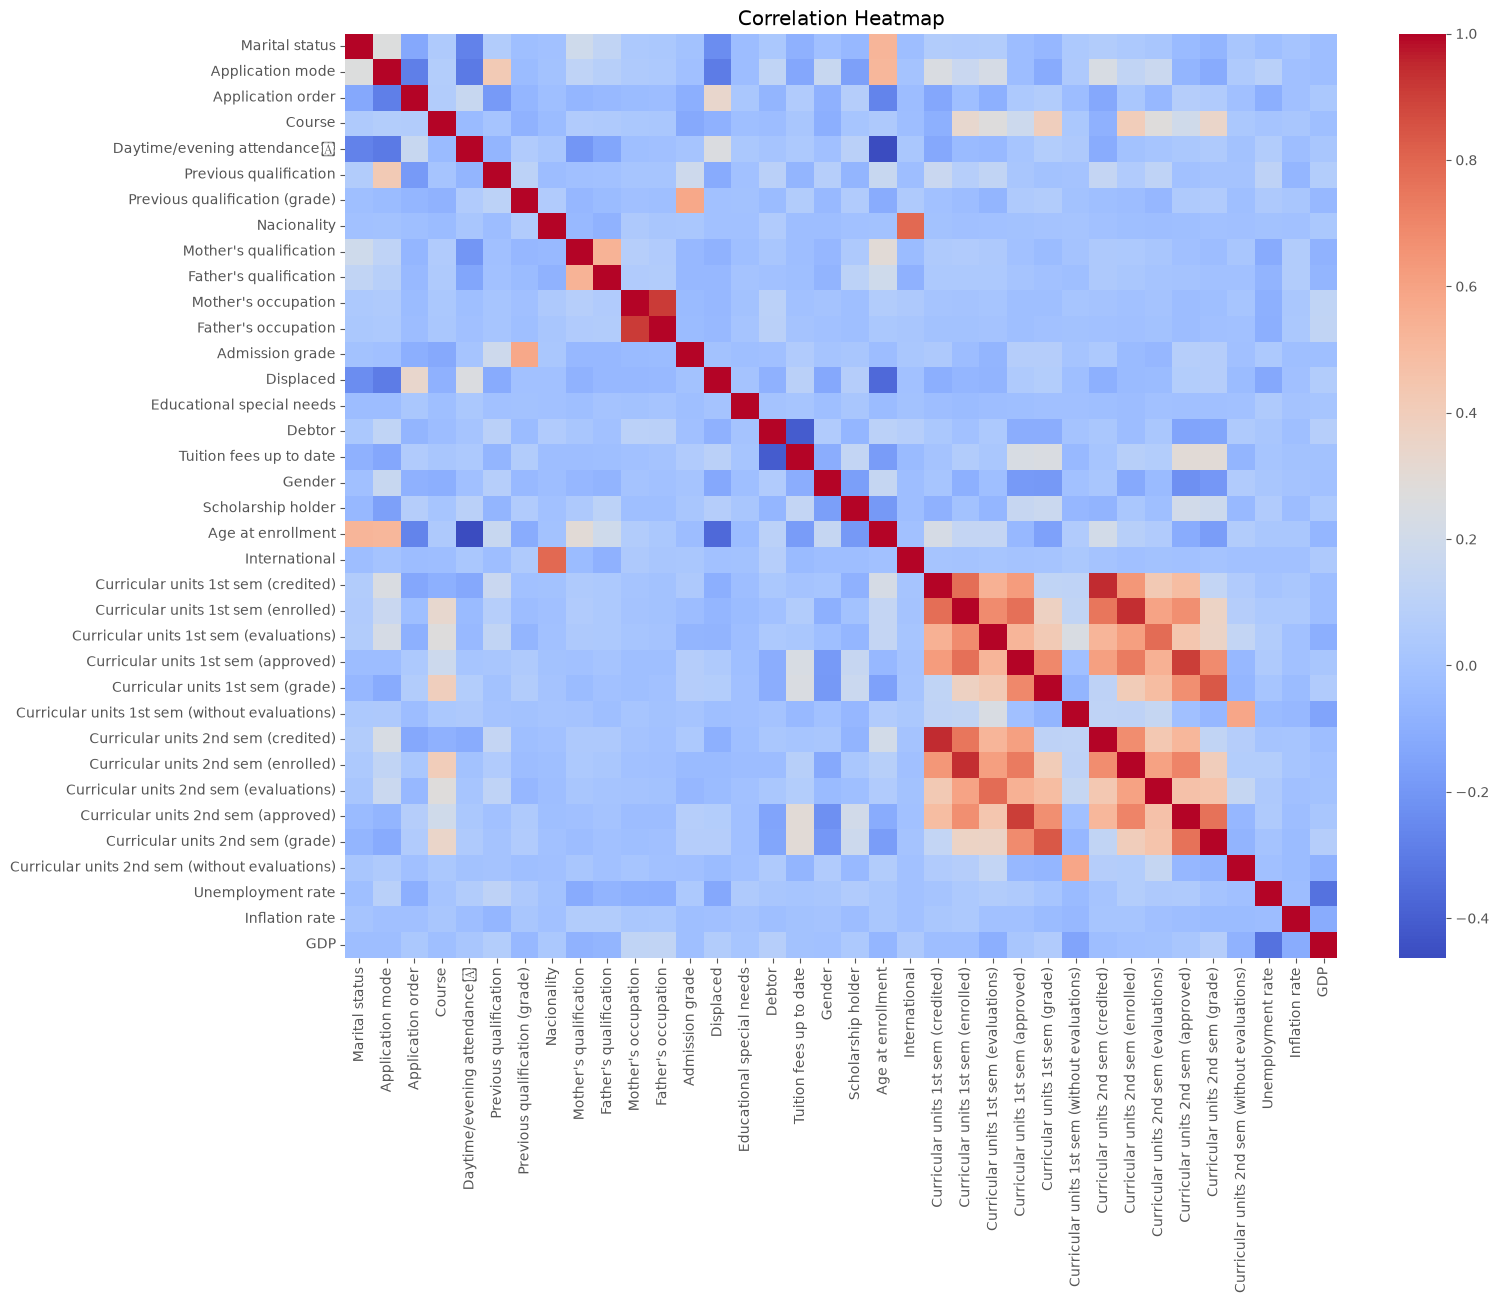

In [116]:
plt.figure(figsize=(16, 12))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.savefig("../results/eda/heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

### Observation

A correlation heatmap was generated to visualize the relationships among the numerical features in the dataset. Most feature pairs exhibit weak to moderate correlations, while a few variables show stronger relationships. The heatmap provides an overall understanding of feature interactions and will be useful during feature analysis and model development.

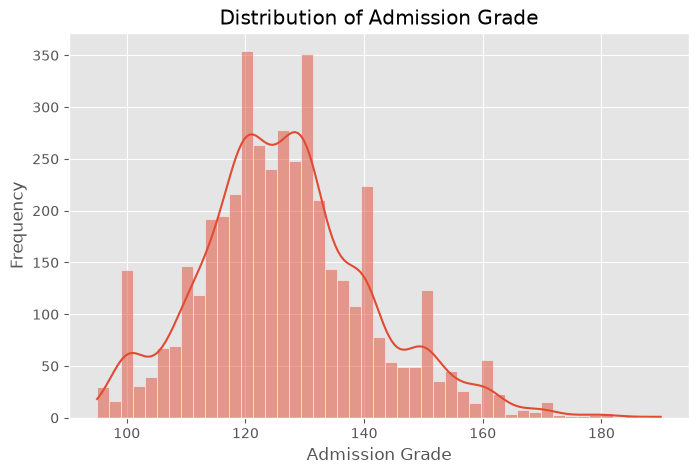

In [117]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Admission grade"], kde=True)

plt.title("Distribution of Admission Grade")
plt.xlabel("Admission Grade")
plt.ylabel("Frequency")

plt.savefig("../results/eda/admission_grade_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

### Observation

The distribution of admission grades is concentrated between approximately 120 and 140, indicating that most students entered the university with moderate admission scores. The histogram exhibits a slight positive (right) skew, with a small number of students having exceptionally high admission grades above 160. No unusual or impossible values were observed in the distribution.

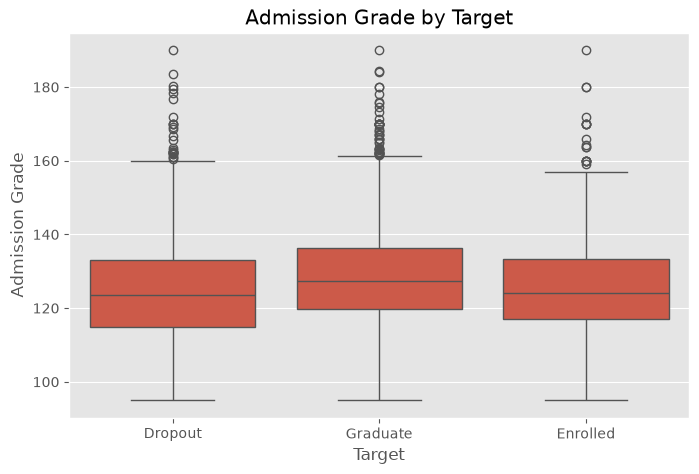

In [118]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Target",
    y="Admission grade"
)

plt.title("Admission Grade by Target")
plt.xlabel("Target")
plt.ylabel("Admission Grade")

plt.savefig("../results/eda/admission_grade_boxplot.png", dpi=300, bbox_inches="tight")

plt.show()

### Observation

The box plot indicates that Graduate students generally have slightly higher admission grades than Dropout students, as reflected by the higher median value. However, the distributions of the three target classes overlap considerably, suggesting that admission grade alone is not sufficient to distinguish student outcomes. Several high-value outliers are present in each class, representing students with exceptionally high admission grades.

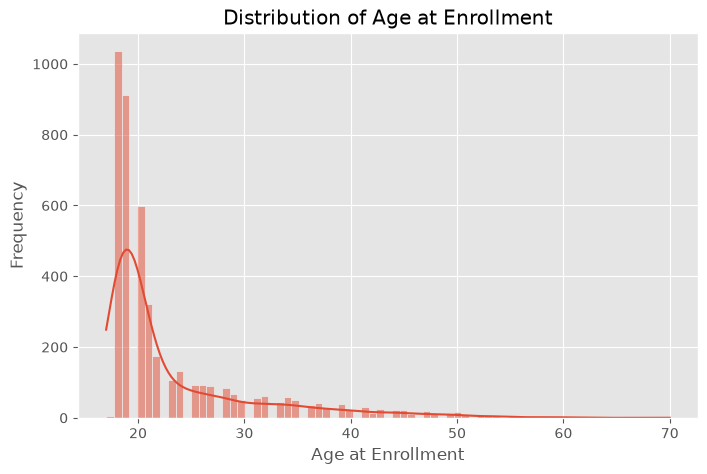

In [119]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Age at enrollment"], kde=True)

plt.title("Distribution of Age at Enrollment")
plt.xlabel("Age at Enrollment")
plt.ylabel("Frequency")

plt.savefig("../results/eda/age_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

### Observation

The histogram illustrates the distribution of students' age at enrollment. Most students enrolled at a relatively young age, while a smaller number of mature students enrolled at older ages. The distribution exhibits a positive (right) skew, indicating that older students are less common.

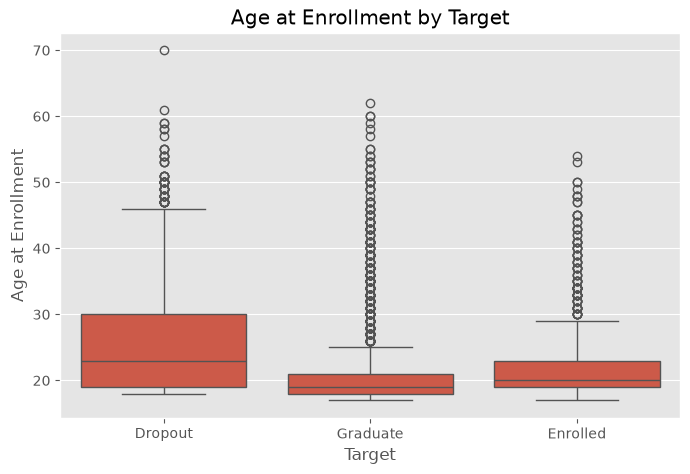

In [120]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Target",
    y="Age at enrollment"
)

plt.title("Age at Enrollment by Target")
plt.xlabel("Target")
plt.ylabel("Age at Enrollment")

plt.savefig("../results/eda/age_boxplot.png", dpi=300, bbox_inches="tight")

plt.show()

### Observation

The box plot compares the age distribution across the three target classes. Differences in the median ages and spread can be observed, indicating that age at enrollment varies among the student outcome groups. Further analysis using machine learning will determine whether age contributes to prediction performance.

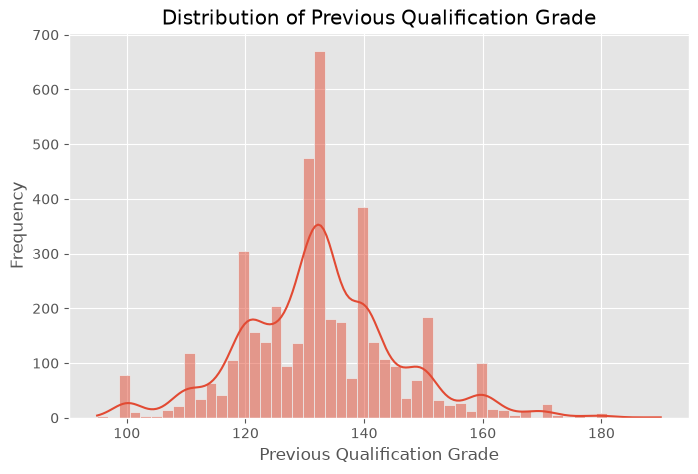

In [121]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Previous qualification (grade)"], kde=True)

plt.title("Distribution of Previous Qualification Grade")
plt.xlabel("Previous Qualification Grade")
plt.ylabel("Frequency")

plt.savefig("../results/eda/previous_qualification_grade_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

### Observation

The previous qualification grades are concentrated within a moderate range, with relatively few students having extremely low or high values. The distribution provides an overview of students' academic performance before university admission.

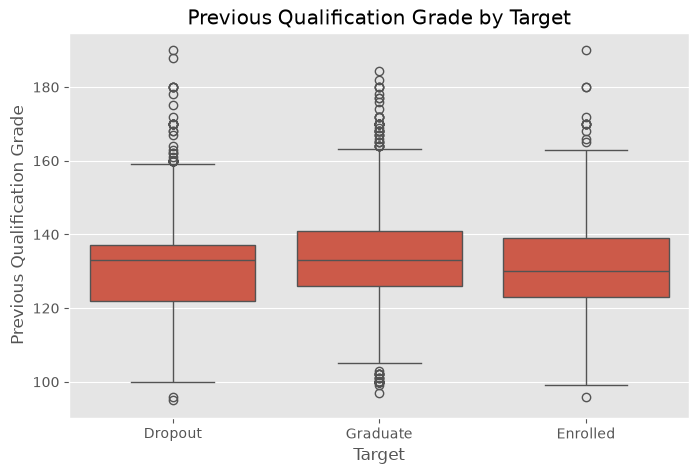

In [122]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Target",
    y="Previous qualification (grade)"
)

plt.title("Previous Qualification Grade by Target")
plt.xlabel("Target")
plt.ylabel("Previous Qualification Grade")

plt.savefig("../results/eda/previous_qualification_grade_boxplot.png", dpi=300, bbox_inches="tight")

plt.show()

### Observation

The box plot compares previous qualification grades across the target classes. While differences in the median values may be observed, there is also considerable overlap among the groups, indicating that previous qualification grade alone may not fully distinguish student outcomes.

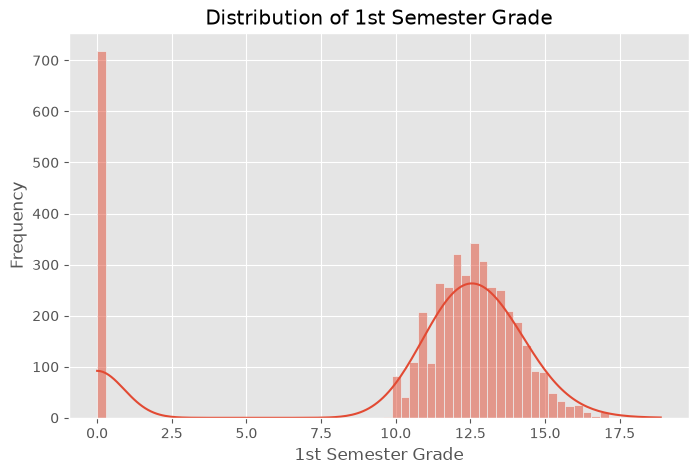

In [123]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Curricular units 1st sem (grade)"], kde=True)

plt.title("Distribution of 1st Semester Grade")
plt.xlabel("1st Semester Grade")
plt.ylabel("Frequency")

plt.savefig("../results/eda/first_semester_grade_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

### Observation

The histogram shows the distribution of first-semester grades among students. The spread of grades provides insight into students' academic performance during the first semester.

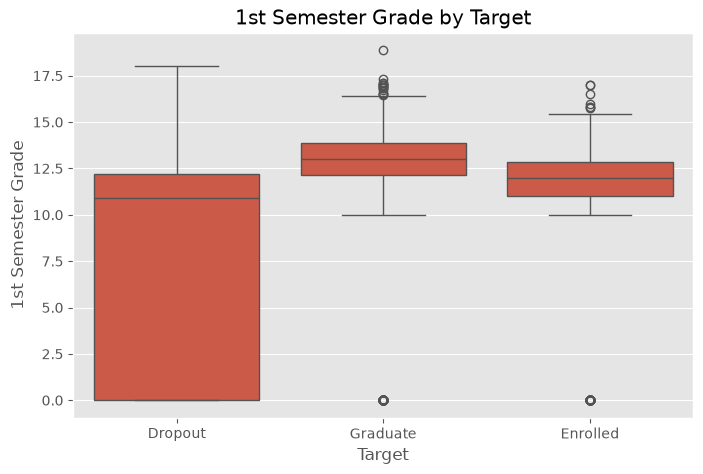

In [124]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Target",
    y="Curricular units 1st sem (grade)"
)

plt.title("1st Semester Grade by Target")
plt.xlabel("Target")
plt.ylabel("1st Semester Grade")

plt.savefig("../results/eda/first_semester_grade_boxplot.png", dpi=300, bbox_inches="tight")

plt.show()

### Observation

The box plot compares first-semester grades across the three target classes. Differences in the median and distribution indicate that students' first-semester academic performance varies among the outcome groups.

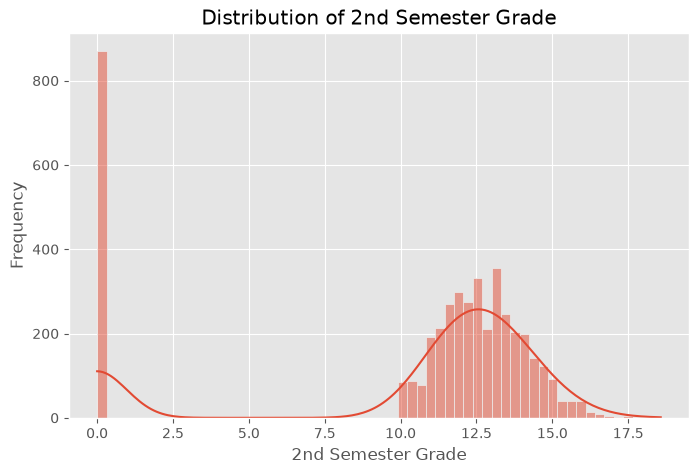

In [125]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Curricular units 2nd sem (grade)"], kde=True)

plt.title("Distribution of 2nd Semester Grade")
plt.xlabel("2nd Semester Grade")
plt.ylabel("Frequency")

plt.savefig("../results/eda/second_semester_grade_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

### Observation

The histogram illustrates the distribution of second-semester grades. Most students achieved grades within a moderate range, while comparatively few students obtained extremely high or low grades.

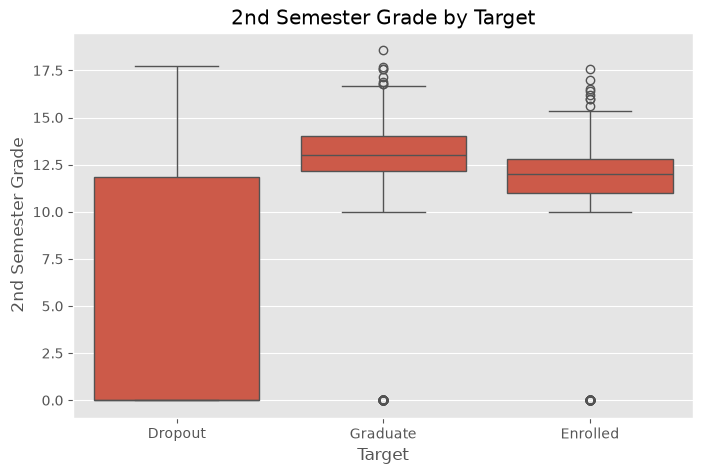

In [126]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Target",
    y="Curricular units 2nd sem (grade)"
)

plt.title("2nd Semester Grade by Target")
plt.xlabel("Target")
plt.ylabel("2nd Semester Grade")

plt.savefig("../results/eda/second_semester_grade_boxplot.png", dpi=300, bbox_inches="tight")

plt.show()

### Observation

The box plot compares second-semester grades across the target classes. The distributions show differences in the median values and spread, suggesting that second-semester academic performance varies among the student outcome groups. Additional analysis through predictive modeling will determine its contribution to student outcome prediction.